<img align="right" width="50" height="50" src="https://avatars3.githubusercontent.com/u/2339114">
<div style="text-align: left">Demo and showcase for Deep Impact AG, March 5 2019</div>

# Extractive Text Summarization with Natural Language Processing
<div style="text-align: right">Muriz Serifovic, 2019</div>

<p align="center">
  <img src="https://i.imgur.com/KdBhz4c.png" alt="sharead"></img>
</p>

<div style="text-align: right">Notebook online available under https://small.cat/pie</div>

# Introduction



Staying relevant in the ever changing technology landscape can be a challenge. At work, we are expected to keep abreast of new computer technologies, web design feels like a constant game of catch up and quitting the race for only a few months months will result in your skill set becoming obsolete.

In short, we can see how knowledge gradually becomes its own unique and important form of currency at a fundamental level. Common resources for developers to brush up their skills include books, podcasts, blog posts, trending GitHub repos, and YouTube videos.

With hundreds of tech talks shared daily, YouTube won in recent years popularity amongst developers - being more commonly their first choice to inform themselves about current technologies. Unfortunately, more often than not these type of videos challenge us to allocate a great chunk of time from our daily life. Expected video lenght range from 20 minutes up to 3 hours, with a busy working schedule we simply put don't have time to watch YouTube videos.

In a recent thread, a Hacker News user wrote:

>*Time management, to me, is a more powerful “skill up” than anything that could keep your GitHub green. When you know you have limited hours in the day and you have hard time commitments, you have no choice but to learn and work efficiently.*

Browsing myself Hacker News for nearly six years, one topic wich regularly shows up is **staying up to date** (Figure 1). Users indicate that they have no time for almost anything besides their day-to-day job.
With methods known from natural language processing, is it possible to densify the content from a YouTube video into one comprehensible PDF file?

<p align="center">
  <img src="https://i.imgur.com/T4ZaB1N.png" alt="hackernews" width="70%"></img>
</p>
<center>Figure 1: Recent threads on Hacker News</center>

# Objective
YouTube videos provide us with auto-generated subtitles. **sharead.app** aims to develop a model to extract useful bits of knowledge from subtitles and provide the user with a PDF file containing the summary.

# Scraping the data

YouTubes captions are stored in a XML tree, which can be easily scraped.

In [70]:
import re
from html import parser, unescape
from urllib.request import urlopen
from xml.etree import ElementTree

import requests
from bs4 import BeautifulSoup


class YouTubeSubtitles:
    class CouldNotFetchSubtitles(Exception):
        """Raises an exception if subtitles could not be found."""

        def __init__(self, youtube_id: str):
            Exception.__init__(
                self,
                "Could not fetch the appropiate subtitles for {url}".format(
                    url=_SubtitleFetcher.BASE_URL.format(
                        youtube_id=youtube_id)))
            self.youtube_id = youtube_id

    @staticmethod
    def get_subtitle(youtube_id: str) -> list:
        """Retrieves the subtitle for the video."""
        try:
            youtube_id = _LinkParser(youtube_id).parse_url()
            return _SubtitleFetcher(youtube_id).parse()
        except Exception:
            raise YouTubeSubtitles.CouldNotFetchSubtitles(youtube_id)


class WebsiteText:
    @staticmethod
    def get_text(url: str) -> tuple:
        """Extracts all the paragraph text from an arbitrary webpage."""

        site = urlopen(url)
        soup = BeautifulSoup(site, "lxml")
        text = ' '.join(map(lambda p: p.text, soup.find_all('p')))
        return soup.title.text, text


class _LinkParser:
    """Extracts unique video id from youtube link."""

    def __init__(self, youtube_link: str):
        self.youtube_link = youtube_link

    def parse_url(self) -> str:
        if 'watch?v' in self.youtube_link:
            youtube_id = re.findall(r'^[^=]+=([^&]+)', self.youtube_link)
        elif 'youtu.be/' in self.youtube_link:
            youtube_id = re.findall(r'youtu\.be/([^&]+)', self.youtube_link)
        else:
            raise YouTubeSubtitles.CouldNotFetchSubtitles(self.youtube_link)
        return youtube_id[0]


class _SubtitleFetcher:
    BASE_URL = "https://www.youtube.com/watch?v={youtube_id}"
    YOUTUBE_API = "https://www.youtube.com/api/{api_url}"
    REGEX = re.compile(r'<[^>]*>', re.IGNORECASE)

    def __init__(self, youtube_id: str):
        self.youtube_id = youtube_id

    def fetch(self) -> str:
        website = requests.get(
            self.BASE_URL.format(youtube_id=self.youtube_id)).text
        timedtext_xml = website.find('timedtext')
        url = self.YOUTUBE_API.format(
            api_url=website[timedtext_xml:timedtext_xml +
                            website[timedtext_xml:].find('"')].replace(
                                '\\u0026', '&').replace('\\', ''))
        return requests.get(url).text

    def parse(self) -> list:
        data = self.fetch()
        return [{
            'text': re.sub(self.REGEX, '', unescape(xml_element.text)),
            'start': float(xml_element.attrib['start']),
        } for xml_element in ElementTree.fromstring(data)]

# Concrete example

Let's take as an example this informative video about artificial intelligence.
The video is over 36 minutes long. Can it be summarized?

video url: https://www.youtube.com/watch?v=jeq-nfpDX4I

<p align="center">
  <img src="https://i.imgur.com/SaYrLjb.png" alt="techtalk" width="100%"></img>
</p>

Scraping the subtitles is the first step for sharead.app

In [46]:
from pprint import pprint
xml_struct = YouTubeSubtitles.get_subtitle(
    "https://www.youtube.com/watch?v=jeq-nfpDX4I")
pprint(xml_struct)
talk_title = "Christian Fehrlin, CEO Deep Impact AG | KMU SWISS Podium 2018 | «Generation next»"
raw_text = ' '.join([i['text'] for i in xml_struct])

[{'start': 4.22, 'text': 'wir starten jetzt gleich mit dem ersten'},
 {'start': 6.099, 'text': 'referenten das ist christian verleihen'},
 {'start': 9.469, 'text': 'er arbeitet seit 1996 in der digitalen'},
 {'start': 13.49, 'text': 'welt und realisiert seit der digitale'},
 {'start': 16.55, 'text': 'und dies ruft iwe projekte mit seiner'},
 {'start': 19.789, 'text': 'firma deep impact treibt unter anderem'},
 {'start': 22.55, 'text': 'die entwicklung von e mail und casey'},
 {'start': 25.48, 'text': 'lösungen zur online voran zur online'},
 {'start': 28.88, 'text': 'identifikation von kunden basierend auf'},
 {'start': 31.429, 'text': 'künstlicher intelligenz'},
 {'start': 33.41, 'text': 'ich nehme an sie wissen was e mail und'},
 {'start': 36.079, 'text': 'crm lösungen sind oder nein ich auch'},
 {'start': 39.59, 'text': 'nicht aber christian verleihen herzlich'},
 {'start': 41.66, 'text': 'willkommen'},
 {'start': 46.93, 'text': 'hallo mr'},
 {'start': 52.82, 'text': 'das klingt seh

# Exploratory Data Analysis

In [107]:
from collections import Counter

import matplotlib.pyplot as plt
import nltk as nlp
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import STOPWORDS, WordCloud

plt.style.use('seaborn-notebook')
%matplotlib inline

Number of words: 3889
Number of unique words: 1133


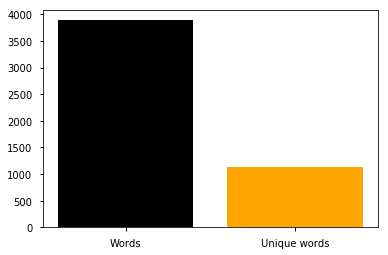

In [6]:
def plot_number_words(raw_text: str):
    n_words = len(raw_text.split())
    n_unique_words = len(set(raw_text.split()))
    print('Number of words: {}\nNumber of unique words: {}'.format(
        n_words, n_unique_words))
    height = [n_words, n_unique_words]
    bars = ("Words", "Unique words")
    y_pos = np.arange(len(bars))
    plt.bar(y_pos, height, color=['black', 'orange'])
    plt.xticks(y_pos, bars)
    plt.plot()

plot_number_words(raw_text)

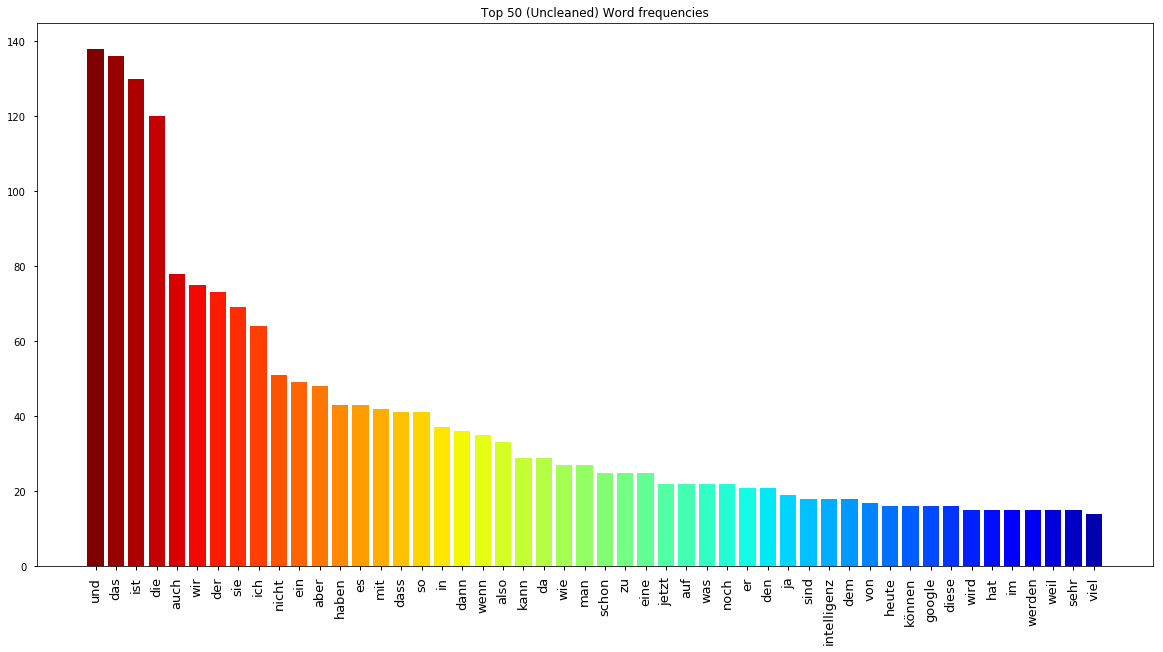

In [7]:
word_list = raw_text.split()
counts = dict(Counter(word_list).most_common(50))

labels, values = zip(*counts.items())
indSort = np.argsort(values)[::-1]
labels = np.array(labels)[indSort]
values = np.array(values)[indSort]
indexes = np.arange(len(labels))

cmap = plt.cm.get_cmap('jet')
colors = cmap(np.arange(cmap.N))[::-5]
plt.figure(figsize=(20, 10))
plt.bar(indexes, values, color=colors)
plt.xticks(indexes, labels, fontsize=13, rotation=90)
plt.title("Top 50 (Uncleaned) Word frequencies")
plt.plot()

## Word clouds

Before creating a word cloud, we want to remove stopwords and lemmatize the text corpus.

In [111]:
wordnet_lemmatizer = WordNetLemmatizer()
words = set(stopwords.words('german')) | set(stopwords.words('english'))
raw_text = ' '.join(wordnet_lemmatizer.lemmatize(word) for word in raw_text.split() if word not in words)

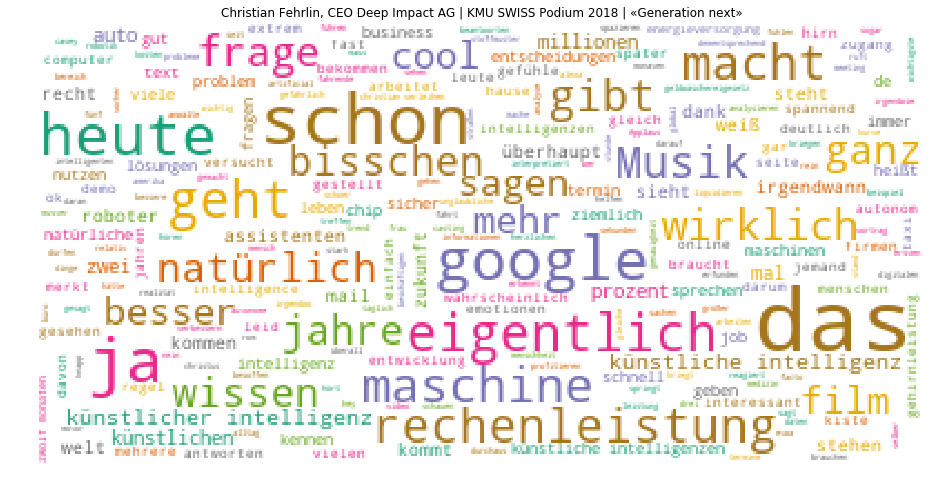

In [118]:
plt.figure(figsize=(24, 18))
plt.subplot(211)
wc = WordCloud(
    background_color="white",
    max_words=1000,
    stopwords=STOPWORDS,
    max_font_size=40)
wc.generate(raw_text)
plt.title(talk_title)
plt.imshow(wc.recolor(colormap='Dark2', random_state=6))
plt.axis('off');

# Subtitles summary

Following approach implements TextRank: Bringing Order into Texts, Mihalcea et al. 2004

In [62]:
import networkx as nx
import numpy as np
import pandas as pd
from nltk.cluster.util import cosine_distance
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity


class ExtractiveSummary:
    """
    Graph-based ranking algorithm for extractive summaries,
    based on top of PageRank.
    """

    def __init__(self, raw_text: tuple, top_k: int=10):
        self.raw_text = raw_text
        self.top_k = top_k
        self._summary = ''

    def get_summary(self) -> str:
        """Creates an extractive summary based on input text corpus."""
        summarize_text = []
        clean_sentences, sentences = self.create_clean_sentences()
        sentence_vector = SentenceVector('glove.6B.100d.txt', clean_sentences)
        sim_mat = SimilarityMatrix(sentence_vector.vector, clean_sentences, len(sentences))
        nx_graph = nx.from_numpy_array(sim_mat.matrix)
        scores = nx.pagerank(nx_graph)
        ranked_sentences = sorted(
            ((scores[i], s) for i, s in enumerate(sentences)), reverse=True)
        for i in range(self.top_k):
            summarize_text.append(ranked_sentences[i][1])
        self._summary = ' '.join(summarize_text)
        return self._summary
        

    def create_clean_sentences(self):
        self.raw_text = (talk_title, self.raw_text)
        sentences = []
        for s in self.raw_text:
            sentences.append(sent_tokenize(s))

        sentences = [y for x in sentences for y in x]
        clean_sentences = pd.Series(sentences).str.replace("[^a-zA-Z]", " ")
        clean_sentences = [s.lower() for s in clean_sentences]
        stop_words = set(stopwords.words('english')) | set(
            stopwords.words('german'))

        def _filter_stopwords(sentence):
            sen_new = " ".join(
                [sen for sen in sentence if sen not in stop_words])
            return sen_new

        clean_sentences = [
            _filter_stopwords(r.split()) for r in clean_sentences
        ]
        return clean_sentences, sentences
    
    def __repr__(self):
        return self._summary


class SimilarityMatrix:
    def __init__(self, sentence_vector, clean_sentences, sentence_lenght):
        self.sentence_vector = sentence_vector
        self.clean_sentences = clean_sentences
        self.sentence_lenght = sentence_lenght
        
    @property
    def matrix(self):
        sim_mat = np.zeros([self.sentence_lenght, self.sentence_lenght])

        for i in range(self.sentence_lenght):
            for j in range(self.sentence_lenght):
                if i != j:
                    sim_mat[i][j] = cosine_similarity(
                        self.sentence_vector[i].reshape(1, 100),
                        self.sentence_vector[j].reshape(1, 100))[0, 0]
        return sim_mat


class SentenceVector:
    def __init__(self, filepath: str, clean_sentences: list):
        self.filepath = filepath
        self.clean_sentences = clean_sentences
        self._sentence_vectors = []

    @property
    def vector(self):
        word_embeddings = dict()
        with open(self.filepath, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                word_embeddings[word] = coefs
        for i in self.clean_sentences:
            if len(i) != 0:
                v = sum([
                    word_embeddings.get(w, np.zeros((100, )))
                    for w in i.split()
                ]) / (len(i.split()) + 0.001)
            else:
                v = np.zeros((100, ))
            self._sentence_vectors.append(v)
        return self._sentence_vectors

Add artificial punctuation every nth sentence.

In [51]:
def synthetic_points(xml_struct, n):
    return ' '.join(
        [v['text'] + '.' * (i % n == 0) for i, v in enumerate(xml_struct)])

# Results

## YouTube video

In [69]:
text = synthetic_points(xml_struct, 5)
extractive_summary = ExtractiveSummary(text)
summary = extractive_summary.get_summary()
print(summary)

und das ist die frage wo geht das hin im ersten video haben wir gesehen dass die maschine entscheidungen fällt. die entwicklung die in anderthalb jahre und stattfindet mit künstlichen intelligenzen. und was wir beobachten ist die elektronische welt ist mit der biologischen noch nicht verknüpft außer mit der stimme über über physik aber wenn ihr diese verschmelzung hinkriegen dass wir unsere hier leistungen mit künstlicher intelligenz bauern können. vor vier oder fünf tagen hat der papa das ist vom amerikanischen militär bekannt gegeben dass sie zwei milliarden investieren in die künstliche intelligenz. auch wenn wir da und geschichten wieder hören dass da ein autonomes fahrzeuge gecrasht ist. drei jahre braucht um überhaupt und ich hab's übliche studieren um überhaupt zu lernen wie man einen löffel zum mund führt er hat es sind unglaubliche dass das wissen viele nicht. und da mehr menschen auf muster rein wollen werden sie uns auch dementsprechend suggerieren können dass sie emotionen 

## Arbitrary Webpage

In [ ]:
url = 'https://deep-impact.ch'
website_text = WebsiteText.get_text(url)
extractive_summary_website = ExtractiveSummary(website_text)
summary_website = extractive_summary_website.get_summary()
print(summary_website)

Deep Impact denken intensiv über die Probleme nach und bauen anschliessend die bestmögliche und effizienteste Lösung.
Von der Idee zum Prototyp in nur 4 Tagen: Wir beschleunigen den Weg von der Idee zur Umsetzung und führen mit dem Design Sprint Framework schneller als je zuvor zur validierten Lösung.
Einfache Lösungen für komplexe geschäftliche Herausforderungen.
Wir designen, entwickeln und vermarkten disruptive Software und führen diese in weniger als 6 Monaten ein.
Wir verfügen über umfangreiche Erfahrung im Erstellen und Betrieb von Plattformen für eine Vielzahl von Branchen.
Lösungen für ungelöste Probleme finden.
Es wird raschmöglichst online veröffentlicht, um das Feedback von Kunden einzuholen.
Durch den Bau von Prototypen und das Testen Ihrer Ideen innerhalb von 2 Wochen, wird das Risiko für ein MVP zu bauen, deutlich reduziert.
Verschiedene Experten von Auftraggeber und uns erarbeiten in kollaborativen Schritten die Lösung.
So entwickeln wir Web Software, die realen Bedür